## Training 

- There are two datasets in this repo, you change them by modifying the `data_folder` variable
    - For some reason `data_folder` aren't shared across the cells in my environment, so the code manually set it again for the cells
        - There are 3 cells that needs the attention, the below cell, the cell for model evaluation, and the cell for feature importance
- The below code train the model 5 times (reps), saves them, then plot the average loss for each rep.
    - The models are saved in `{data_folder}_models` 
    - For each rep, the model first pretrain the GCNs before training all of them with VCDN (for more info, please check the previous report)


=== Rep 1/5 ===

Pretrain GCNs...

Training...
Test: Epoch 0  ACC 0.415
Test: Epoch 50  ACC 0.528
Test: Epoch 100  ACC 0.585
Test: Epoch 150  ACC 0.698
Test: Epoch 200  ACC 0.755
Test: Epoch 250  ACC 0.774
Test: Epoch 300  ACC 0.764
Test: Epoch 350  ACC 0.783
Test: Epoch 400  ACC 0.783
Test: Epoch 450  ACC 0.792
Test: Epoch 500  ACC 0.792

=== Rep 2/5 ===

Pretrain GCNs...

Training...
Test: Epoch 0  ACC 0.557
Test: Epoch 50  ACC 0.783
Test: Epoch 100  ACC 0.830
Test: Epoch 150  ACC 0.821
Test: Epoch 200  ACC 0.821
Test: Epoch 250  ACC 0.840
Test: Epoch 300  ACC 0.858
Test: Epoch 350  ACC 0.840
Test: Epoch 400  ACC 0.858
Test: Epoch 450  ACC 0.830
Test: Epoch 500  ACC 0.849

=== Rep 3/5 ===

Pretrain GCNs...

Training...
Test: Epoch 0  ACC 0.453
Test: Epoch 50  ACC 0.623
Test: Epoch 100  ACC 0.764
Test: Epoch 150  ACC 0.821
Test: Epoch 200  ACC 0.858
Test: Epoch 250  ACC 0.858
Test: Epoch 300  ACC 0.821
Test: Epoch 350  ACC 0.840
Test: Epoch 400  ACC 0.840
Test: Epoch 450  ACC 0.849
T

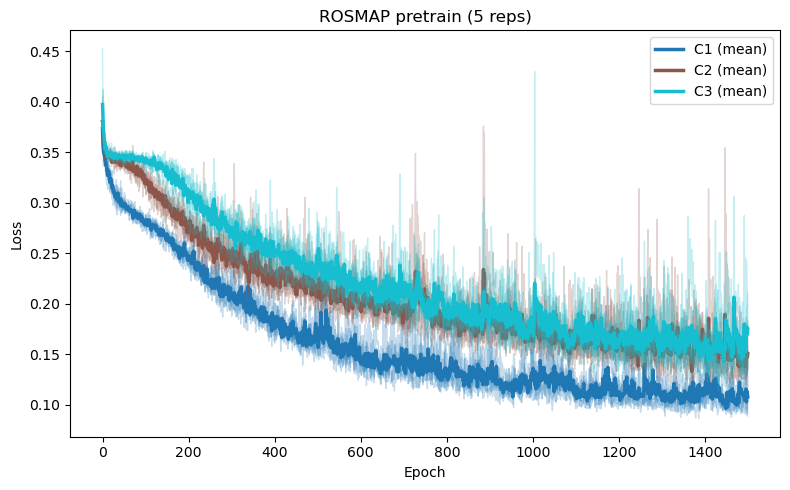

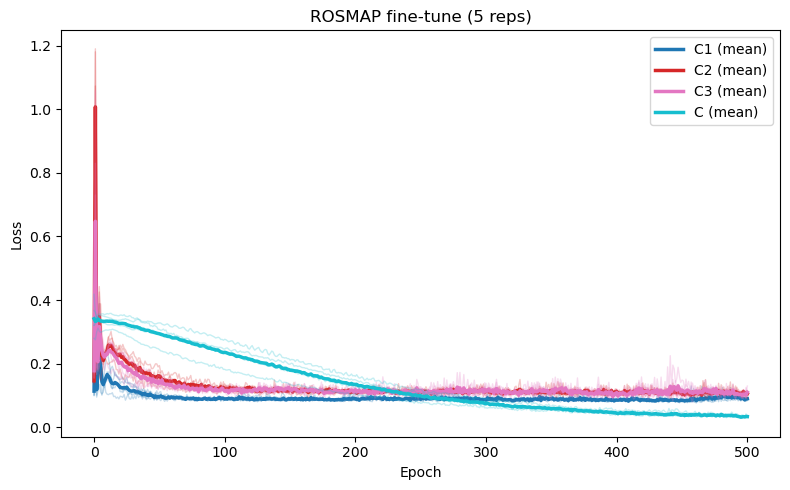

In [38]:
from mogonet_training_logger import run_reps_with_history, plot_phase_histories
import os


data_folder = "ROSMAP" # change to "BRCA" for multi-class (5)

pretrain_histories, finetune_histories = run_reps_with_history(
    data_folder=data_folder, 
    view_list=[1, 2, 3],
    num_class=5 if data_folder == "BRCA" else 2, 
    lr_e_pretrain=1e-3,
    lr_e=5e-4,
    lr_c=1e-3,
    num_epoch_pretrain=1500,
    num_epoch=500,
    num_reps=5,
    model_folder=os.path.join(data_folder, "models"),  # set to None to skip saving
)

plot_phase_histories(pretrain_histories, phase_name="Pretrain", title=f"{data_folder} pretrain (5 reps)")
plot_phase_histories(finetune_histories, phase_name="Fine-tune", title=f"{data_folder} fine-tune (5 reps)")

## Model Evaluation

- These loads the models saved above then evaluate them

In [ ]:
import os
import copy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from cal_perf_metrics import cal_test_metrics
from train_test import train_test

def run_cross_validation(data_folder, view_list, num_class, num_splits=5):
    all_auc, all_acc, all_bacc, all_f1 = [], [], [], []
    all_precision, all_recall, all_se, all_sp = [], [], [], []

    for i in range(num_splits):
        print(f"Run {i+1}/{num_splits}...")

        model_folder = os.path.join(data_folder, 'models')
        rep_folder = os.path.join(model_folder, str(i + 1)) if model_folder else None

        # Performance metrics    
        m = cal_test_metrics(data_folder, rep_folder, view_list, num_class)
        all_auc.append(m["auc"])
        all_acc.append(m["acc"])
        all_bacc.append(m["bacc"])
        all_f1.append(m["f1"])
        all_precision.append(m["precision"])
        all_recall.append(m["recall"])
        all_se.append(m["sensitivity"])
        all_sp.append(m["specificity"])

    return all_auc, all_acc, all_bacc, all_f1, all_precision, all_recall, all_se, all_sp

def plot_results(data_folder, all_metrics, output_dir="results"):
    os.makedirs(output_dir, exist_ok=True)
    output_dir = os.path.join(data_folder, output_dir)
    
    metric_names = ["AUC", "Accuracy", "BalAccuracy", "F1", "Precision", "Recall", "Sensitivity", "Specificity"]
    for metric, name in zip(all_metrics, metric_names):
        sns.histplot(metric, kde=True)
        plt.title(f"{name} Distribution")
        plt.savefig(os.path.join(output_dir, f"{name}_MOGONET_reps.png"))
        plt.clf()

    # Save mean performances
    mean_perf = {name.lower(): np.mean(metric) for name, metric in zip(metric_names, all_metrics)}
    with open(os.path.join(output_dir, "MeanPerf_MOGONET_reps.txt"), "w") as f:
        for key, value in mean_perf.items():
            f.write(f"{key}: {value}\n")

change the `data_folder` here to match your working dataset

In [ ]:
data_folder = "ROSMAP" # Change to BRCA 
num_class = 5 if data_folder == 'BRCA' else 2
print(data_folder)

all_metrics = run_cross_validation(data_folder, view_list, num_class)
plot_results(data_folder, all_metrics)

ROSMAP
Run 1/5...
Run 2/5...
Run 3/5...
Run 4/5...
Run 5/5...


<Figure size 640x480 with 0 Axes>

ROSMAP/results
Displaying AUC_MOGONET_reps.png


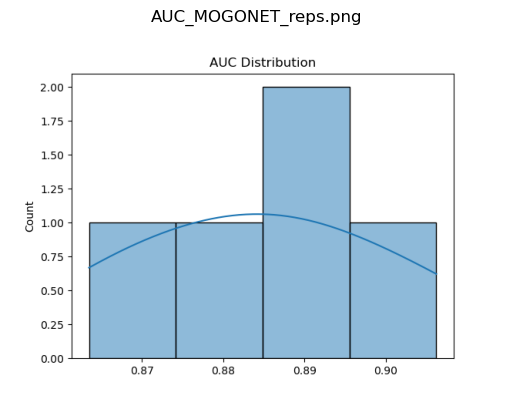

Displaying F1_MOGONET_reps.png


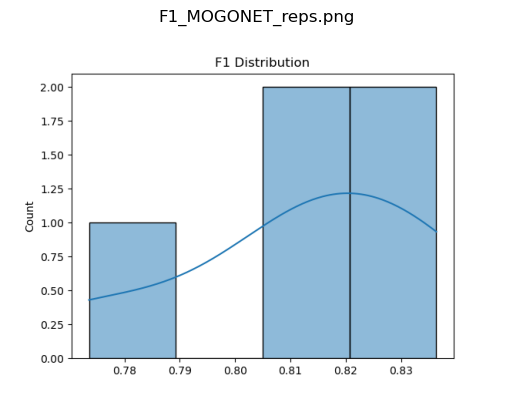

Displaying Precision_MOGONET_reps.png


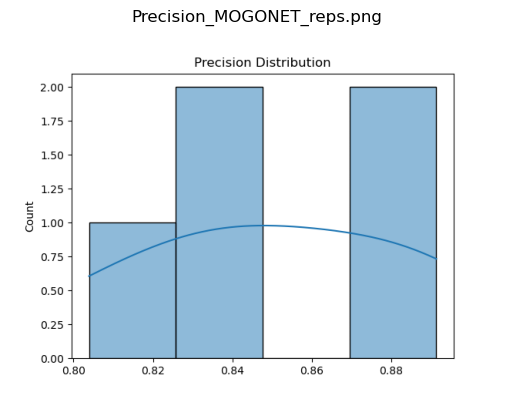

Displaying BalAccuracy_MOGONET_reps.png


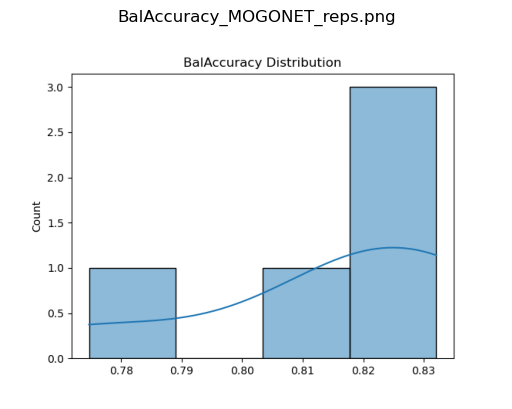

Displaying Specificity_MOGONET_reps.png


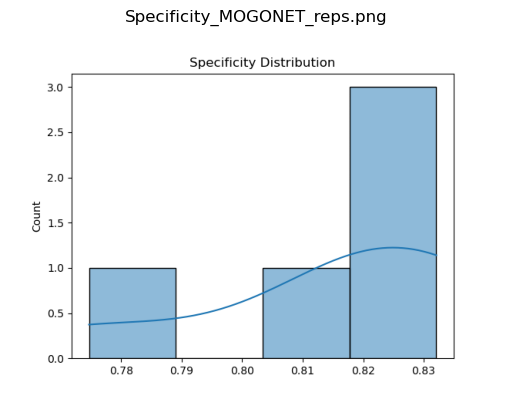

Displaying Recall_MOGONET_reps.png


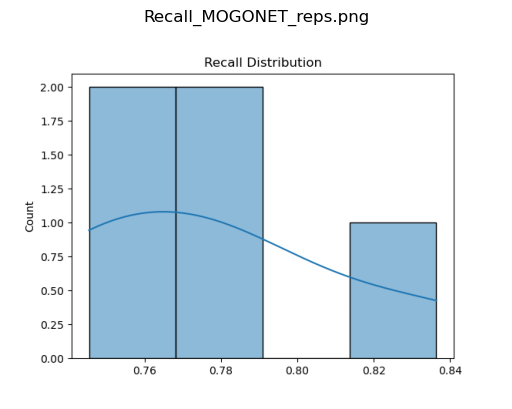

Displaying Accuracy_MOGONET_reps.png


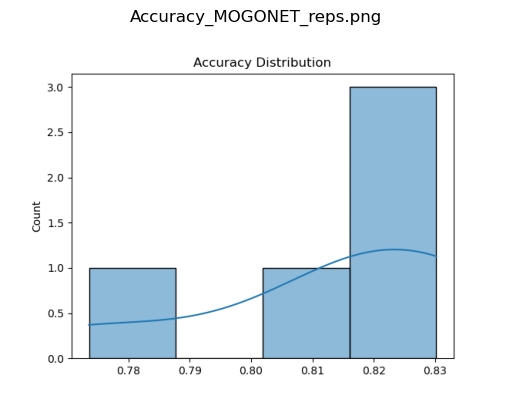

Displaying Sensitivity_MOGONET_reps.png


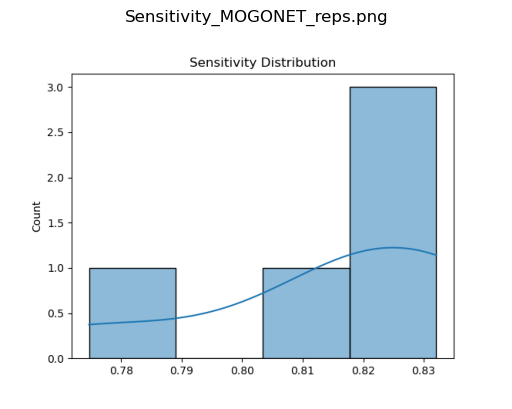

In [36]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os

# Path to the results folder
results_dir = "results"
results_dir = os.path.join(data_folder, results_dir)
print(results_dir)

# List all image files in the folder
image_files = glob.glob(os.path.join(results_dir, "*.png"))

# Check if any files were found
if not image_files:
    print("No images found in the results folder.")
else:
    # Display each image one by one
    for img_path in image_files:
        print(f"Displaying {os.path.basename(img_path)}")
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis('off')  # Remove axes for better visualization
        plt.title(os.path.basename(img_path))  # Add title with filename
        plt.show()


## Feature Importance

- Feature Importance is performed by an ablation process (removing specific parts)
    - In this case the ablated (removed) components are the features 
        - We remove one feature at a time and measure the performance drop. The feature that makes the model do worst without is deemed as the most important.
            - The metric used for this is the F1 score
- Please note that as we are constructing a new adjacency matrix (very computationally costly operation) every time we ablate a feature. It can take a while for the below code to finish execution.

Rank	Feature name
1	cg27091787
2	hsa-miR-423-3p
3	ENSG00000155980.6
4	ENSG00000117266.11
5	cg00398048
6	cg22518733
7	cg06946880
8	hsa-miR-33a
9	cg12447832
10	hsa-miR-362-3p
11	ENSG00000168743.8
12	cg02008416
13	hsa-miR-640
14	hsa-miR-491-5p
15	hsa-miR-873
16	cg14387505
17	hsa-miR-206
18	hsa-miR-125a-5p
19	hsa-miR-106a_hsa-miR-17
20	hsa-miR-548b-3p
21	ENSG00000099194.4
22	hsa-miR-577
23	cg17385448
24	cg07232688
25	hsa-miR-340
26	ENSG00000204219.5
27	ENSG00000105643.3
28	cg01869233
29	cg25736482
30	ENSG00000182310.7


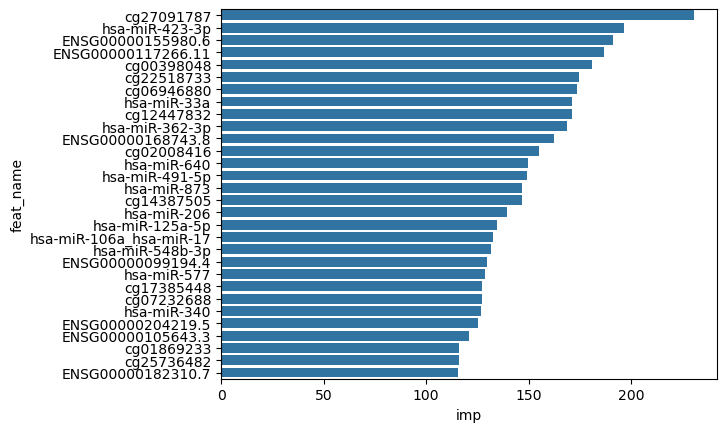

In [39]:
""" Example for biomarker identification
"""
import os
import copy
from feat_importance import cal_feat_imp, summarize_imp_feat

if __name__ == "__main__":
    data_folder = 'ROSMAP'
    model_folder = os.path.join(data_folder, 'models')
    view_list = [1,2,3]
    if data_folder == 'ROSMAP':
        num_class = 2
    if data_folder == 'BRCA':
        num_class = 5

    featimp_list_list = []
    for rep in range(5):
        featimp_list = cal_feat_imp(data_folder, os.path.join(model_folder, str(rep+1)), 
                                    view_list, num_class)
        featimp_list_list.append(copy.deepcopy(featimp_list))

    output_dir = os.path.join(data_folder, "results")

    df_featimp_top = summarize_imp_feat(featimp_list_list)
    df_featimp_top.to_csv(os.path.join(output_dir, "FeatImp.csv"), index=False)
    feat_imp_plot = sns.barplot(data=df_featimp_top, x="imp", y="feat_name")
    feat_imp_plot.get_figure().savefig(os.path.join(output_dir, "Feature_imp_MOGONET.png"))
    